# Summative Lab – Analytics Firm Clients: Customer Reviews Analysis

This notebook is a **starter notebook** for the three parts of the lab:

1. NLP  
2. Time Series  
3. Neural Networks  

Use the comments and TODO prompts to guide your work. The notebook is intentionally incomplete so you can implement the analysis yourself.


## Part 1: NLP

In this section, you will clean and preprocess review text, explore frequent words and bigrams, and visualize key language patterns in the dataset.


In [ ]:
# =========================
# Part 1: NLP Starter Code
# =========================

# TODO: Import the libraries you need for:
# - data handling
# - plotting
# - text preprocessing
# - tokenization / stopwords / lemmatization
# - counting words and bigrams

# Example:
# import pandas as pd

# TODO: Download any required NLTK resources.

# TODO: Load the dataset.
# Hint: The file used in this lab is 'amazon_reviews_lab.csv'
# df = ...

# TODO: Explore the dataset.
# Suggested checks:
# - shape
# - value counts for the rating column
# - preview the first few rows

# TODO: Create preprocessing tools such as:
# - stop_words
# - lemmatizer

# TODO: Write a function called preprocess_text(text) that:
# 1. converts text to lowercase
# 2. removes URLs
# 3. removes punctuation
# 4. tokenizes the text
# 5. keeps alphabetic tokens only
# 6. removes stopwords
# 7. lemmatizes the remaining tokens
# 8. returns the cleaned tokens

# def preprocess_text(text):
#     pass

# TODO: Apply your preprocessing function to the review text column
# and store the output in a new column such as 'processed_tokens'.

# TODO: Combine all tokens into one list so you can compute word frequencies.

# TODO: Use Counter to identify the most common words.

# TODO: Generate bigrams from the token list and identify the most common bigrams.

# TODO: Create at least one visualization of the most common words.
# You may also choose to visualize the most common bigrams.

# Reflection prompt:
# What do the most common words or phrases suggest about customer sentiment or product experience?


In [ ]:
# TODO: Import the libraries you need for:
# - data handling
# - plotting
# - text preprocessing
# - tokenization / stopwords / lemmatization
# - counting words and bigrams

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
from collections import Counter

In [ ]:
# TODO: Download any required NLTK resources.
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.util import ngrams

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

In [ ]:
# TODO: Load the dataset.
# Hint: The file used in this lab is 'amazon_reviews_lab.csv'
# Load dataset
df = pd.read_csv("amazon_reviews_lab.csv")

In [ ]:
# TODO: Explore the dataset.
# Suggested checks:
# - shape
# - value counts for the rating column
# - preview the first few rows
# Basic exploration
print("Shape: \n" ,df.shape)
print("\nDescribe: \n" ,df.describe())
print("\n", df["rating"].value_counts().sort_index(), "\n")

print("head")
print(df.head())

In [ ]:
# TODO: Create preprocessing tools such as:
# - stop_words
# - lemmatizer
# Preprocessing setup
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

In [ ]:
# TODO: Write a function called preprocess_text(text) that:
# 1. converts text to lowercase
# 2. removes URLs
# 3. removes punctuation
# 4. tokenizes the text
# 5. keeps alphabetic tokens only
# 6. removes stopwords
# 7. lemmatizes the remaining tokens
# 8. returns the cleaned tokens
def preprocess_text(text):
 text = str(text).lower()
 text = re.sub(r"http\S+|www\S+|https\S+", "", text)
 text = text.translate(str.maketrans("", "", string.punctuation))
 tokens = word_tokenize(text)
 tokens = [token for token in tokens if token.isalpha()]
 tokens = [token for token in tokens if token not in stop_words]
 tokens = [lemmatizer.lemmatize(token) for token in tokens]
 return tokens

In [ ]:
# TODO: Apply your preprocessing function to the review text column
# and store the output in a new column such as 'processed_tokens'.

df["processed_tokens"] = df["review_text"].apply(preprocess_text)

In [ ]:
# TODO: Combine all tokens into one list so you can compute word frequencies.
# TODO: Use Counter to identify the most common words.

# Word frequency
all_tokens = [token for tokens in df["processed_tokens"] for token in tokens]
word_counts = Counter(all_tokens)

# print("\nTop words:", word_counts.most_common(20))

print("\nTop 20 words:")
for word, count in word_counts.most_common(20):
    print(f"{word}: {count}")

In [ ]:
# TODO: Generate bigrams from the token list and identify the most common bigrams.
# Bigrams
bigram_counts = Counter(ngrams(all_tokens, 2))
# print("\nTop bigrams:", bigram_counts.most_common(20))

print("\nTop 20 bigrams:")
for bigram, count in bigram_counts.most_common(20):
    print(f"{' '.join(bigram)}: {count}")

In [ ]:
# TODO: Create at least one visualization of the most common words.
# You may also choose to visualize the most common bigrams.

# Visualization
common_words = pd.DataFrame(word_counts.most_common(20), columns=["word", "count"])

plt.figure(figsize=(10, 6))
sns.barplot(data=common_words, x="count", y="word")
plt.title("Top 20 Most Common Words")
plt.xlabel("Count")
plt.ylabel("Word")
plt.tight_layout()
plt.show()

In [ ]:
# You may also choose to visualize the most common bigrams.

# Visualization
common_bigrams = pd.DataFrame(bigram_counts.most_common(20), columns=["bigram", "count"])

# convert bigram tuples to strings
common_bigrams["bigram"] = common_bigrams["bigram"].apply(lambda x: " ".join(x))

plt.figure(figsize=(10, 6))
sns.barplot(data=common_bigrams, x="count", y="bigram")
plt.title("Top 20 Most Bigrmas")
plt.xlabel("Count")
plt.ylabel("Bigram")
plt.tight_layout()
plt.show()

# Reflection prompt:
What do the most common words or phrases suggest about customer sentiment or product experience?

- Looking at the top 20 most common words, the sentiment seems to be positive as three of the top works include `like`, `great`, and `good`. There are no words in the top 20 most common that appear to have any negative sentiment.

- Looking at the top 20 most common bigrams further confirms the postive sentiment, as top bigrams include `work great`, `work well`, and `easy install`.  This shows that users commonly rate the product as performing well and easy to install.  Similar to the top word counts, there are no top bigrams that appear to indicate any negative sentiment.

- One potentially concerning bigram to investigate further is `battery life`.  We cannot tell by the bigrams alone, but it is possibly that users are complaining about how long the battery life lasts.  

## Part 2: Time Series

In this section, you will analyze review activity over time by converting timestamps, resampling the data, and visualizing trends in review volume and ratings.


In [ ]:
# ==============================
# Part 2: Time Series Starter Code
# ==============================

# TODO: Import the libraries you need.

# TODO: Load the same review dataset.
# df = ...

# TODO: Convert the timestamp column to datetime format.

# TODO: Inspect the date range in the dataset.
# Suggested checks:
# - earliest timestamp
# - latest timestamp

# TODO: Resample the data by month to calculate:
# 1. monthly review count
# 2. monthly average rating

# Suggested variable names:
# monthly_review_count = ...
# monthly_avg_rating = ...

# TODO: Plot monthly review volume over time.

# TODO: Plot average monthly rating over time.

# TODO: Compute a rolling average for the monthly average rating.
# A 3-month rolling average is a good starting point.

# TODO: Plot both:
# - the original monthly average rating
# - the rolling average
# on the same figure.

# Reflection prompt:
# What overall trends do you notice in review activity and customer ratings over time?


In [ ]:
# TODO: Import the libraries you need.

# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
import numpy as np

In [ ]:
# TODO: Load the same review dataset.
# Load dataset
df = pd.read_csv("amazon_reviews_lab.csv")

df.head()

In [ ]:
# TODO: Convert the timestamp column to datetime format.
# Convert timestamp
# df["timestamp"] = pd.to_datetime(df["timestamp"])

df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")

print("Missing/invalid timestamps:", df["timestamp"].isna().sum())

In [ ]:
# TODO: Inspect the date range in the dataset.
# Suggested checks:
# - earliest timestamp
# - latest timestamp

# Basic checks
print("Earliest Timestamp:", df["timestamp"].min())
print("Latest Timestamp:", df["timestamp"].max())
print("Time Range:", df["timestamp"].max() - df["timestamp"].min())


In [ ]:
# TODO: Resample the data by month to calculate:
# 1. monthly review count
# 2. monthly average rating

# Resampling
monthly_review_count = df.resample("ME", on="timestamp").size()
monthly_avg_rating = df.resample("ME", on="timestamp")["rating"].mean()

print("Monthly review counts:")
display(monthly_review_count.head())

print("Monthly average ratings:")
display(monthly_avg_rating.head())

In [ ]:
# TODO: Plot monthly review volume over time.
# Plot review volume
plt.figure(figsize=(12, 6))
plt.plot(monthly_review_count.index, monthly_review_count.values)
plt.title("Monthly Review Volume")
plt.xlabel("Date")
plt.ylabel("Number of Reviews")
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import matplotlib.dates as mdates

# Limit data to December 2009 and later
monthly_review_count_2009 = monthly_review_count[monthly_review_count.index >= "2009-12-01"]

# Calculate linear trend line
x = np.arange(len(monthly_review_count_2009))
trend = np.polyfit(x, monthly_review_count_2009.values, 1)
trend_line = np.polyval(trend, x)

# Plot review volume
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(monthly_review_count_2009.index, monthly_review_count_2009.values, label="Monthly Review Volume")

# Add linear trend line
ax.plot(monthly_review_count_2009.index, trend_line, label="Linear Trend", linestyle="--", linewidth=2)

plt.title("Monthly Review Volume (2009 and Later)")
plt.xlabel("Date")
plt.ylabel("Number of Reviews")
plt.legend()

# Show x-axis ticks/grid every month
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

# Rotate date labels
plt.xticks(rotation=90)

plt.grid(True)
plt.tight_layout()
plt.show()

# Display trend slope
print(f"Monthly trend slope: {trend[0]:.2f} reviews per month")

In [ ]:
# TODO: Plot average monthly rating over time.
# Plot average rating
plt.figure(figsize=(12, 6))
plt.plot(monthly_avg_rating.index, monthly_avg_rating.values)
plt.title("Average Monthly Rating")
plt.xlabel("Date")
plt.ylabel("Average Rating")
plt.ylim(0.9, 5.1)
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Limit data to DEC 2009 and later
monthly_avg_rating_2009 = monthly_avg_rating[monthly_avg_rating.index >= "2009-12-01"]

# Plot average rating
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(monthly_avg_rating_2009.index, monthly_avg_rating_2009.values)

plt.title("Average Monthly Rating (2009 and Later)")
plt.xlabel("Date")
plt.ylabel("Average Rating")
plt.ylim(0.9, 5.1)

# Show every month on the x-axis
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

# Rotate month labels for readability
plt.xticks(rotation=90)

# Show grid for each month
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# TODO: Compute a rolling average for the monthly average rating.
# A 3-month rolling average is a good starting point.
# Rolling average
rolling_avg = monthly_avg_rating.rolling(window=3).mean()

In [ ]:
# TODO: Plot both:
# - the original monthly average rating
# - the rolling average
# on the same figure.
plt.figure(figsize=(12, 6))
plt.plot(monthly_avg_rating.index, monthly_avg_rating.values, label="Monthly Average", marker="o", markersize=3, alpha=0.6)
plt.plot(rolling_avg.index, rolling_avg.values, label="3-Month Rolling Average")
plt.title("Rating Trends Over Time")
plt.xlabel("Date")
plt.ylabel("Average Rating")
plt.legend()
plt.ylim(0.9, 5.1)
plt.tight_layout()
plt.grid(True)
plt.show()


In [ ]:
# Limit data to DEC 2009 and later
monthly_avg_rating_2009 = monthly_avg_rating[monthly_avg_rating.index >= "2009-12-01"]
rolling_avg_2009 = rolling_avg[rolling_avg.index >= "2009-12-01"]

# Calculate linear trend line
x = np.arange(len(monthly_avg_rating_2009))
trend2 = np.polyfit(x, monthly_avg_rating_2009.values, 1)
trend_line = np.polyval(trend2, x)

# Plot rating trends
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(monthly_avg_rating_2009.index,monthly_avg_rating_2009.values, label="Monthly Average", marker="o", markersize=3, alpha=0.6)
ax.plot(rolling_avg_2009.index, rolling_avg_2009.values, label="3-Month Rolling Average")

# Add linear trend line
ax.plot(monthly_avg_rating_2009.index, trend_line, label="Linear Trend", linestyle="--", linewidth=2)

plt.title("Rating Trends Over Time (2009 and Later)")
plt.xlabel("Date")
plt.ylabel("Average Rating")
plt.legend()

# Show every other month on the x-axis
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

# Rotate month labels
plt.xticks(rotation=90)
# Grid lines at each month
plt.grid(True)
plt.tight_layout()
plt.show()

# Display trend slope
print(f"Monthly trend slope: {trend2[0]:.2f} rating per month")

# Reflection prompt:
What overall trends do you notice in review activity and customer ratings over time?

- When looking at the volume of monthly reviews, we see a general increase in the number of reviews each year, with a trend line slope of 0.35 reviews per month.   This means that on average there is one addtional review every 3 months.  We also see spikes in reviews around the holidays, to include JAN2011, JAN2012, JAN2013, and DEC & FEB 2014.  These peaks indicate that the holiday season causes an increase in the number of reviews, likely due to higher purchasing during these periods.  

- When looking at the average customer ratings, the trend line also indicates that ratings are getting more positive over time, increasing by about 0.01 each month between DEC2009 to AUG2014.  
   - NOV 2012 had lowest average rating of ~3.0, but this month also had one of the lowest total number of reviews of 5, so the sample size is much lower than most other mothns.  
   - Similarly, JUL 2010 had the highest average rating of ~5.0, but this month also had the lowest total number of reviews at 3.  Again, the sample size in this month is much lower, and could be considered an outlier.  
   - Both of these months show the value in using the rolling average, so that peaks or valleys in activity do not skew the results or subsequent analysis. 



## Part 3: Neural Networks

In this section, you will transform text reviews into numerical features, train a neural network to predict ratings, and evaluate model performance.


In [ ]:
# ===================================
# Part 3: Neural Networks Starter Code
# ===================================

# TODO: Import the libraries you need for:
# - data handling
# - train/test splitting
# - text vectorization
# - model building
# - model evaluation

# You will likely need tools from:
# - pandas / numpy
# - sklearn
# - tensorflow / keras

# TODO: Load the dataset.
# df = ...

# TODO: Define:
# X as the review text column
# y as the rating column
# If needed, adjust y so the classes are numbered appropriately for your model.

# TODO: Vectorize the text using TF-IDF.
# Suggested question:
# - How many features do you want to keep?

# vectorizer = ...
# X_tfidf = ...

# TODO: Split the data into training and testing sets.
# Use stratify=y to preserve class balance.

# TODO: One-hot encode the target values if your neural network setup requires it.

# TODO: Build a neural network model.
# Include:
# - an input layer
# - at least one hidden layer
# - an output layer suitable for multi-class classification

# model = ...

# TODO: Compile the model.
# Think about:
# - optimizer
# - loss function
# - evaluation metric(s)

# TODO: Train the model and store the training history.
# history = ...

# TODO: Evaluate the model on the test set.

# TODO: Generate predictions on the test set.

# TODO: Create a classification report and/or confusion matrix to assess performance.

# Reflection prompt:
# Which rating classes does the model predict well, and which ones are harder to classify?

In [9]:
# TODO: Import the libraries you need for:
# - data handling
# - train/test splitting
# - text vectorization
# - model building
# - model evaluation

# You will likely need tools from:
# - pandas / numpy
# - sklearn
# - tensorflow / keras

# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical

In [2]:
# TODO: Load the dataset.
# Load dataset
df = pd.read_csv("amazon_reviews_lab.csv")
df.head()

,product_id,rating,review_text,review_summary,review_time_raw,unix_review_time,timestamp,sentiment_label,review_length_words
0,6301977173,2,This film is definitely not for anyone who is ...,The best of Mark Twain's work - left out!,"05 12, 2000",9.580896e+08,2000-05-12,negative,302
1,6301977173,5,This movie was playing at Radio City Music Hal...,The best Tom Sawyer i ever saw.,"08 26, 2002",1.030320e+09,2002-08-26,positive,168
2,6301977173,1,I would love to buy this movie as I have been ...,Why no Widescreen?,"08 6, 2005",1.123286e+09,2005-08-06,negative,60
3,6301977173,1,The advertisment for this DVD on Amazon was in...,False advertising on this DVD,"09 11, 2005",1.126397e+09,2005-09-11,negative,104
4,9575871979,5,I bought some of these to try with a light usi...,Work GREAT!!,"10 15, 2007",1.192406e+09,2007-10-15,positive,60


In [ ]:
# TODO: Define:
# X as the review text column
# y as the rating column
# If needed, adjust y so the classes are numbered appropriately for your model.
# Features and target
# X = df["review_text"].astype(str)
X = df["review_text"].fillna("").astype(str)
y = df["rating"] - 1 # convert 1–5 → 0–4

print("Classes:", sorted(y.unique()))

Classes: [0, 1, 2, 3, 4]


In [4]:
# TODO: Split the data into training and testing sets.
# Use stratify=y to preserve class balance.
# Train-test split
X_train_text, X_test_text, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

print("Training samples:", len(X_train_text))
print("Testing samples:", len(X_test_text))

Training samples: 797
Testing samples: 200


In [7]:
# TODO: Vectorize the text using TF-IDF.
# Suggested question:
# - How many features do you want to keep?
# test 5,000 features

# Vectorization
vectorizer = TfidfVectorizer(max_features=5000, stop_words="english", min_df=2, ngram_range=(1, 2))

# Learn vocabulary ONLY from training data
X_train = vectorizer.fit_transform(X_train_text)
X_test = vectorizer.transform(X_test_text)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (797, 5000)
Testing shape: (200, 5000)


In [10]:
# TODO: One-hot encode the target values if your neural network setup requires it.
# One-hot encoding
y_train_cat = to_categorical(y_train, num_classes=5)
y_test_cat = to_categorical(y_test, num_classes=5)

In [14]:
# TODO: Build a neural network model.
# Include:
# - an input layer
# - at least one hidden layer
# - an output layer suitable for multi-class classification

# Model
model = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(5, activation="softmax")
])

# TODO: Compile the model.
# Think about:
# - optimizer
# - loss function
# - evaluation metric(s)

model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │       640,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 648,709 (2.47 MB)

 Trainable params: 648,709 (2.47 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# TODO: Train the model and store the training history.
# Train
# history = model.fit(X_train, y_train_cat, validation_split=0.2, epochs=10, batch_size=32, verbose=1)

# use early stopping instead of exactly 10 epochs, set epochs to 20 - the training will stop early if the validation loss doesn't improve for 2 consecutive epochs.
# restore_best_weights=True then returns the model to the best-performing epoch rather than simply keeping the final epoch.
early_stopping = EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)

history = model.fit(X_train, y_train_cat, validation_split=0.2, epochs=20, batch_size=64, callbacks=[early_stopping], verbose=1)

Epoch 1/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - accuracy: 0.5322 - loss: 1.5587 - val_accuracy: 0.5813 - val_loss: 1.4876
Epoch 2/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.5824 - loss: 1.3817 - val_accuracy: 0.5813 - val_loss: 1.3197
Epoch 3/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5824 - loss: 1.1974 - val_accuracy: 0.5813 - val_loss: 1.2248
Epoch 4/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5824 - loss: 1.0726 - val_accuracy: 0.5813 - val_loss: 1.1951
Epoch 5/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5824 - loss: 0.9644 - val_accuracy: 0.5813 - val_loss: 1.1597
Epoch 6/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5824 - loss: 0.8562 - val_accuracy: 0.5813 - val_loss: 1.1411
Epoch 7/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5981 - loss: 0.7469 - val_accuracy: 0.5813 - val_loss: 1.1379
Epoch 8/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.7002 - loss: 0.6317 - val_accuracy: 0.6062 - v

In [17]:
# TODO: Evaluate the model on the test set.
# Evaluate
test_loss, test_accuracy = model.evaluate(X_test, y_test_cat, verbose=0)
print("Test accuracy:", test_accuracy)
print(f"Test Loss: {test_loss:.4f}")

Test accuracy: 0.574999988079071
Test Loss: 1.1386


In [18]:
# TODO: Generate predictions on the test set.
# Predictions
y_pred_prob = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_prob, axis=1)

In [24]:
# TODO: Create a classification report and/or confusion matrix to assess performance.
# Classificaiton report
print(classification_report(
        y_test,
        y_pred,
        target_names=[
            "1 Star",
            "2 Stars",
            "3 Stars",
            "4 Stars",
            "5 Stars"
        ],
        zero_division=0
    )
)



              precision    recall  f1-score   support

      1 Star       0.50      0.06      0.11        17
     2 Stars       0.00      0.00      0.00        10
     3 Stars       0.00      0.00      0.00        19
     4 Stars       0.12      0.03      0.04        38
     5 Stars       0.59      0.97      0.74       116

    accuracy                           0.57       200
   macro avg       0.24      0.21      0.18       200
weighted avg       0.41      0.57      0.45       200



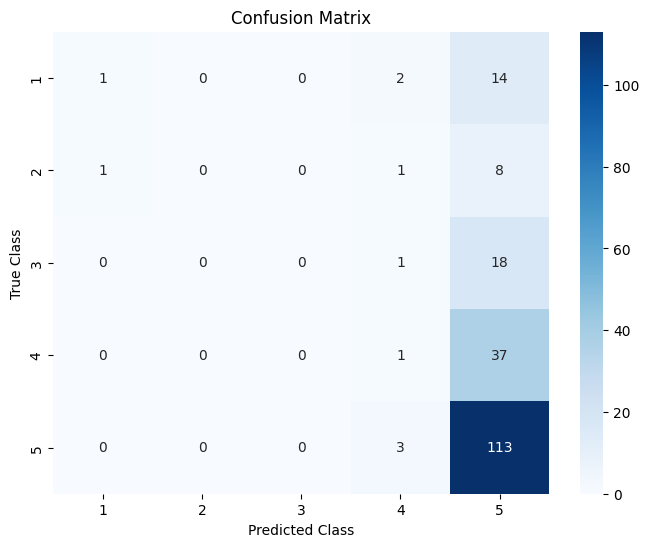

In [26]:
#Confusion matrix

cm = confusion_matrix(
    y_test, 
    y_pred,
    labels=[0, 1, 2, 3, 4]
    )
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[1, 2, 3, 4, 5], yticklabels=[1, 2, 3, 4, 5])
plt.title("Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.show()


# Reflection prompt:
Which rating classes does the model predict well, and which ones are harder to classify?
